## PM2.5 Air Pollution Forecasting using Time Series Models (Urban Microclimate Dataset)

## Importing Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Data Loading

In [ ]:
df = pd.read_excel("/content/urban micro climate blr_delhi(3).xlsx")

In [ ]:
df

,City,Latitude,Longitude,Datetime,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,...,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season
0,Bengaluru,12.9716,77.5946,2022-08-05 00:00:00,0,3,Monsoon,Night,20.0,97,...,16.0,3,NaN,NaN,NaN,NaN,Good,0,0,0
1,Bengaluru,12.9716,77.5946,2022-08-05 03:00:00,0,3,Monsoon,Night,19.6,96,...,16.0,2,NaN,NaN,NaN,NaN,Good,0,0,0
2,Bengaluru,12.9716,77.5946,2022-08-05 06:00:00,0,3,Monsoon,Early_Morning,19.8,95,...,19.0,2,17.0,17.0,12.0,Good,Good,0,0,0
3,Bengaluru,12.9716,77.5946,2022-08-05 08:00:00,0,3,Monsoon,Early_Morning,21.1,89,...,20.0,1,17.0,17.0,12.0,Good,Good,0,0,0
4,Bengaluru,12.9716,77.5946,2022-08-05 09:00:00,0,3,Monsoon,Morning,21.9,85,...,20.0,1,16.0,16.0,12.0,Good,Good,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29035,Delhi,28.6139,77.2090,2025-11-26 17:00:00,0,4,Post_Monsoon,Afternoon,20.5,45,...,150.0,11,112.0,112.0,76.0,Unhealthy,Poor,0,0,1
29036,Delhi,28.6139,77.2090,2025-11-26 18:00:00,0,4,Post_Monsoon,Evening,19.3,51,...,155.0,10,113.0,113.0,77.0,Unhealthy,Very_Poor,0,0,1
29037,Delhi,28.6139,77.2090,2025-11-26 20:00:00,0,4,Post_Monsoon,Evening,18.0,55,...,117.0,11,116.0,116.0,78.0,Unhealthy,Very_Poor,0,0,1
29038,Delhi,28.6139,77.2090,2025-11-26 21:00:00,0,4,Post_Monsoon,Night_Late,17.1,58,...,81.0,13,118.0,118.0,80.0,Unhealthy,Very_Poor,0,0,1


## Data Preprocessing

In [ ]:
data = df.copy()

In [ ]:
data.head()

,City,Latitude,Longitude,Datetime,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,...,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season
0,Bengaluru,12.9716,77.5946,2022-08-05 00:00:00,0,3,Monsoon,Night,20.0,97,...,16.0,3,NaN,NaN,NaN,NaN,Good,0,0,0
1,Bengaluru,12.9716,77.5946,2022-08-05 03:00:00,0,3,Monsoon,Night,19.6,96,...,16.0,2,NaN,NaN,NaN,NaN,Good,0,0,0
2,Bengaluru,12.9716,77.5946,2022-08-05 06:00:00,0,3,Monsoon,Early_Morning,19.8,95,...,19.0,2,17.0,17.0,12.0,Good,Good,0,0,0
3,Bengaluru,12.9716,77.5946,2022-08-05 08:00:00,0,3,Monsoon,Early_Morning,21.1,89,...,20.0,1,17.0,17.0,12.0,Good,Good,0,0,0
4,Bengaluru,12.9716,77.5946,2022-08-05 09:00:00,0,3,Monsoon,Morning,21.9,85,...,20.0,1,16.0,16.0,12.0,Good,Good,0,0,0


In [ ]:
data.tail()

,City,Latitude,Longitude,Datetime,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,...,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season
29035,Delhi,28.6139,77.209,2025-11-26 17:00:00,0,4,Post_Monsoon,Afternoon,20.5,45,...,150.0,11,112.0,112.0,76.0,Unhealthy,Poor,0,0,1
29036,Delhi,28.6139,77.209,2025-11-26 18:00:00,0,4,Post_Monsoon,Evening,19.3,51,...,155.0,10,113.0,113.0,77.0,Unhealthy,Very_Poor,0,0,1
29037,Delhi,28.6139,77.209,2025-11-26 20:00:00,0,4,Post_Monsoon,Evening,18.0,55,...,117.0,11,116.0,116.0,78.0,Unhealthy,Very_Poor,0,0,1
29038,Delhi,28.6139,77.209,2025-11-26 21:00:00,0,4,Post_Monsoon,Night_Late,17.1,58,...,81.0,13,118.0,118.0,80.0,Unhealthy,Very_Poor,0,0,1
29039,Delhi,28.6139,77.209,2025-11-26 23:00:00,0,4,Post_Monsoon,Night_Late,16.2,64,...,36.0,17,126.0,126.0,83.0,Unhealthy,Very_Poor,0,0,1


In [ ]:
data

,City,Latitude,Longitude,Datetime,Is_Weekend,Quarter,Season,Time_of_Day,Temp_2m_C,Humidity_Percent,...,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,AQI_Category,PM25_Category_India,Temp_Inversion,Festival_Period,Crop_Burning_Season
0,Bengaluru,12.9716,77.5946,2022-08-05 00:00:00,0,3,Monsoon,Night,20.0,97,...,16.0,3,NaN,NaN,NaN,NaN,Good,0,0,0
1,Bengaluru,12.9716,77.5946,2022-08-05 03:00:00,0,3,Monsoon,Night,19.6,96,...,16.0,2,NaN,NaN,NaN,NaN,Good,0,0,0
2,Bengaluru,12.9716,77.5946,2022-08-05 06:00:00,0,3,Monsoon,Early_Morning,19.8,95,...,19.0,2,17.0,17.0,12.0,Good,Good,0,0,0
3,Bengaluru,12.9716,77.5946,2022-08-05 08:00:00,0,3,Monsoon,Early_Morning,21.1,89,...,20.0,1,17.0,17.0,12.0,Good,Good,0,0,0
4,Bengaluru,12.9716,77.5946,2022-08-05 09:00:00,0,3,Monsoon,Morning,21.9,85,...,20.0,1,16.0,16.0,12.0,Good,Good,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29035,Delhi,28.6139,77.2090,2025-11-26 17:00:00,0,4,Post_Monsoon,Afternoon,20.5,45,...,150.0,11,112.0,112.0,76.0,Unhealthy,Poor,0,0,1
29036,Delhi,28.6139,77.2090,2025-11-26 18:00:00,0,4,Post_Monsoon,Evening,19.3,51,...,155.0,10,113.0,113.0,77.0,Unhealthy,Very_Poor,0,0,1
29037,Delhi,28.6139,77.2090,2025-11-26 20:00:00,0,4,Post_Monsoon,Evening,18.0,55,...,117.0,11,116.0,116.0,78.0,Unhealthy,Very_Poor,0,0,1
29038,Delhi,28.6139,77.2090,2025-11-26 21:00:00,0,4,Post_Monsoon,Night_Late,17.1,58,...,81.0,13,118.0,118.0,80.0,Unhealthy,Very_Poor,0,0,1


In [ ]:
! gdown --id 11-hBI8wcx-T4lqrTOfWJevVvH2XQx0UO

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=11-hBI8wcx-T4lqrTOfWJevVvH2XQx0UO
To: /content/urban micro climate blr_delhi(3).xlsx
100% 8.33M/8.33M [00:00<00:00, 21.2MB/s]


In [ ]:
data.columns

Index(['City', 'Latitude', 'Longitude', 'Datetime', 'Is_Weekend', 'Quarter',
       'Season', 'Time_of_Day', 'Temp_2m_C', 'Humidity_Percent', 'Dew_Point_C',
       'Humidity_Category', 'Wind_Speed_10m_kmh', 'Wind_Dir_10m',
       'Wind_Gusts_kmh', 'Wind_Category', 'Wind_Stagnation',
       'Precipitation_mm', 'Rain_mm', 'Is_Raining', 'Heavy_Rain',
       'Pressure_MSL_hPa', 'Surface_Pressure_hPa', 'Solar_Radiation_Wm2',
       'Direct_Radiation_Wm2', 'Diffuse_Radiation_Wm2', 'Cloud_Cover_Percent',
       'Cloud_Low_Percent', 'Cloud_Mid_Percent', 'Cloud_High_Percent',
       'Is_Daytime', 'Sunshine_Seconds', 'PM2_5_ugm3', 'PM10_ugm3', 'PM_Ratio',
       'CO_ugm3', 'NO2_ugm3', 'SO2_ugm3', 'O3_ugm3', 'Dust_ugm3', 'AOD',
       'US_AQI', 'US_AQI_PM25', 'US_AQI_PM10', 'US_AQI_NO2', 'US_AQI_O3',
       'US_AQI_CO', 'EU_AQI', 'EU_AQI_PM25', 'EU_AQI_PM10', 'AQI_Category',
       'PM25_Category_India', 'Temp_Inversion', 'Festival_Period',
       'Crop_Burning_Season'],
      dtype='object')

In [ ]:
data.shape

(29040, 55)

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29040 entries, 0 to 29039
Data columns (total 55 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   City                   29040 non-null  object        
 1   Latitude               29040 non-null  float64       
 2   Longitude              29040 non-null  float64       
 3   Datetime               29040 non-null  datetime64[ns]
 4   Is_Weekend             29040 non-null  int64         
 5   Quarter                29040 non-null  int64         
 6   Season                 29040 non-null  object        
 7   Time_of_Day            29040 non-null  object        
 8   Temp_2m_C              29040 non-null  float64       
 9   Humidity_Percent       29040 non-null  int64         
 10  Dew_Point_C            29040 non-null  float64       
 11  Humidity_Category      29040 non-null  object        
 12  Wind_Speed_10m_kmh     29040 non-null  float64       
 13  W

In [ ]:
data.isnull().sum()

,0
City,0
Latitude,0
Longitude,0
Datetime,0
Is_Weekend,0
Quarter,0
Season,0
Time_of_Day,0
Temp_2m_C,0
Humidity_Percent,0


## Data Cleaning

In [ ]:
aqi_cols = [
    "US_AQI", "US_AQI_PM25", "US_AQI_PM10", "US_AQI_O3",
    "EU_AQI", "EU_AQI_PM25", "EU_AQI_PM10"
]

for col in aqi_cols:
    data[col].fillna(data[col].median(), inplace=True)


/tmp/ipykernel_656/2788745564.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data[col].fillna(data[col].median(), inplace=True)


In [ ]:
data = data.dropna(subset=["AQI_Category"])

In [ ]:
data.isnull().sum()

,0
City,0
Latitude,0
Longitude,0
Datetime,0
Is_Weekend,0
Quarter,0
Season,0
Time_of_Day,0
Temp_2m_C,0
Humidity_Percent,0


## Exploratory Data Analysis

In [ ]:
data.groupby("City")["PM2_5_ugm3"].mean()

,PM2_5_ugm3
City,
Bengaluru,20.905380
Delhi,72.449885


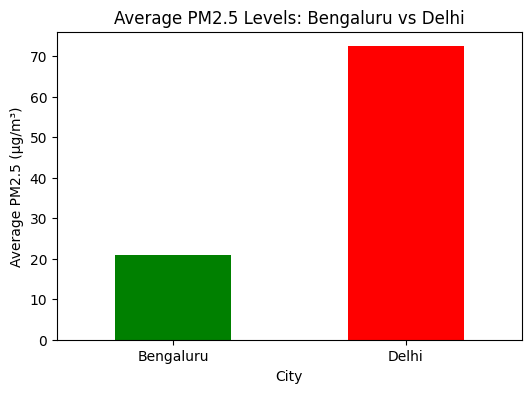

In [ ]:
import matplotlib.pyplot as plt

avg_pm25 = data.groupby("City")["PM2_5_ugm3"].mean()

plt.figure(figsize=(6,4))
avg_pm25.plot(kind='bar', color=['green','red'])
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Average PM2.5 Levels: Bengaluru vs Delhi")
plt.xticks(rotation=0)
plt.show()

In [ ]:
data.describe()

,Latitude,Longitude,Datetime,Is_Weekend,Quarter,Temp_2m_C,Humidity_Percent,Dew_Point_C,Wind_Speed_10m_kmh,Wind_Dir_10m,...,US_AQI_PM10,US_AQI_NO2,US_AQI_O3,US_AQI_CO,EU_AQI,EU_AQI_PM25,EU_AQI_PM10,Temp_Inversion,Festival_Period,Crop_Burning_Season
count,28889.000000,28889.000000,28889,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,...,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,28889.000000,28889.0,28889.000000,28889.000000
mean,20.752953,77.402781,2024-03-30 01:04:14.962096640,0.285922,2.605698,24.054831,67.159334,16.275305,10.110031,192.459691,...,59.336772,16.047631,46.989754,6.523763,74.858666,68.347191,61.596663,0.0,0.106338,0.199384
min,12.971600,77.209000,2022-08-05 06:00:00,0.000000,1.000000,3.200000,5.000000,-6.800000,0.000000,0.000000,...,1.000000,0.000000,0.000000,1.000000,7.000000,1.000000,1.000000,0.0,0.000000,0.000000
25%,12.971600,77.209000,2023-06-02 03:00:00,0.000000,2.000000,20.300000,52.000000,12.000000,6.300000,97.000000,...,24.000000,5.000000,21.000000,3.000000,40.000000,38.000000,27.000000,0.0,0.000000,0.000000
50%,12.971600,77.594600,2024-03-29 00:00:00,0.000000,3.000000,23.800000,72.000000,17.600000,9.400000,226.000000,...,47.000000,11.000000,33.000000,5.000000,70.000000,69.000000,61.000000,0.0,0.000000,0.000000
75%,28.613900,77.594600,2025-01-23 23:00:00,1.000000,4.000000,28.000000,86.000000,19.800000,13.200000,280.000000,...,79.000000,22.000000,49.000000,7.000000,96.000000,89.000000,85.000000,0.0,0.000000,0.000000
max,28.613900,77.594600,2025-11-26 23:00:00,1.000000,4.000000,45.800000,100.000000,28.800000,36.100000,360.000000,...,500.000000,107.000000,246.000000,94.000000,282.000000,255.000000,282.000000,0.0,1.000000,1.000000
std,7.821184,0.192801,NaN,0.451860,1.113124,6.167265,22.761996,5.859844,5.205611,100.333618,...,53.343305,15.304928,42.002583,6.340244,44.440186,38.228977,43.242302,0.0,0.308275,0.399544


In [ ]:
pm25_time = data.groupby("Time_of_Day")["PM2_5_ugm3"].mean()
pm25_time


,PM2_5_ugm3
Time_of_Day,
Afternoon,36.153822
Early_Morning,47.887993
Evening,49.940573
Morning,39.240137
Night,50.967498
Night_Late,55.087067


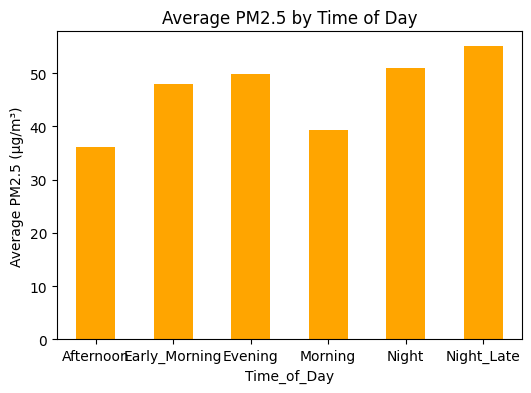

In [ ]:
plt.figure(figsize=(6,4))
pm25_time.plot(kind='bar', color='orange')
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Average PM2.5 by Time of Day")
plt.xticks(rotation=0)
plt.show()


In [ ]:
pm25_season = data.groupby("Season")["PM2_5_ugm3"].mean()
print(pm25_season)


Season
Monsoon         30.312677
Post_Monsoon    58.541858
Summer          42.966054
Winter          64.718788
Name: PM2_5_ugm3, dtype: float64


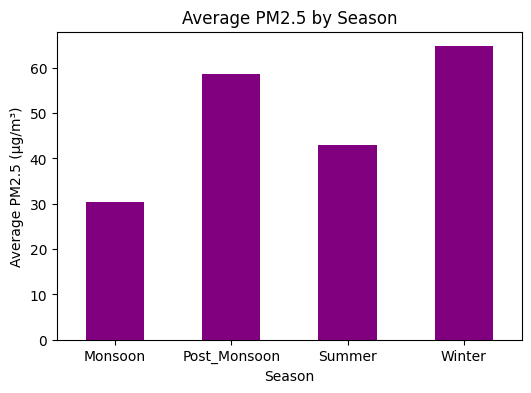

In [ ]:
plt.figure(figsize=(6,4))
pm25_season.plot(kind='bar', color='purple')
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Average PM2.5 by Season")
plt.xticks(rotation=0)
plt.show()


In [ ]:
pm25_weekend = data.groupby("Is_Weekend")["PM2_5_ugm3"].mean()
print(pm25_weekend)


Is_Weekend
0    46.342702
1    47.055448
Name: PM2_5_ugm3, dtype: float64


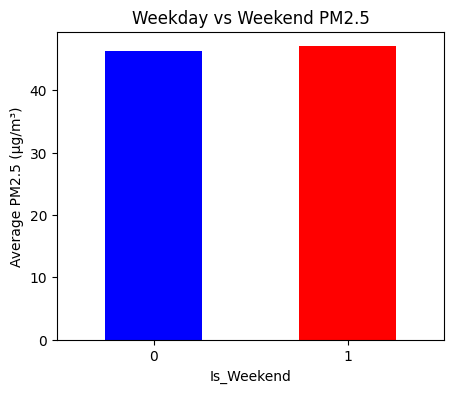

In [ ]:
plt.figure(figsize=(5,4))
pm25_weekend.plot(kind='bar', color=['blue','red'])
plt.ylabel("Average PM2.5 (µg/m³)")
plt.title("Weekday vs Weekend PM2.5")
plt.xticks(rotation=0)
plt.show()


In [ ]:
corr = data[["PM2_5_ugm3","Temp_2m_C","Humidity_Percent"]].corr()
print(corr)


                  PM2_5_ugm3  Temp_2m_C  Humidity_Percent
PM2_5_ugm3          1.000000  -0.261567          0.028220
Temp_2m_C          -0.261567   1.000000         -0.608317
Humidity_Percent    0.028220  -0.608317          1.000000


## Time Series Preparation

In [ ]:
data["Datetime"] = pd.to_datetime(data["Datetime"])
data = data.sort_values("Datetime")
data = data.set_index("Datetime")

ts = data["PM2_5_ugm3"]

/tmp/ipykernel_656/3606544228.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Datetime"] = pd.to_datetime(data["Datetime"])


In [ ]:
print(data.index.name)

Datetime


## Stationarity Check (ADF Test)

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts)

print("ADF Statistic:", result[0])
print("p-value:", result[1])


ADF Statistic: -8.18871671839443
p-value: 7.77197925484281e-13


## Train-Test Split

In [ ]:
train_size = int(len(ts) * 0.8)

train = ts[:train_size]
test = ts[train_size:]

print("Train size:", len(train))
print("Test size:", len(test))


Train size: 23111
Test size: 5778


## ARIMA Model

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train, order=(1,0,1))  # d=0 because stationary
model_fit = model.fit()

print(model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             PM2_5_ugm3   No. Observations:                23111
Model:                 ARIMA(1, 0, 1)   Log Likelihood             -116478.110
Date:                Fri, 20 Mar 2026   AIC                         232964.221
Time:                        14:12:25   BIC                         232996.413
Sample:                             0   HQIC                        232974.680
                              - 23111                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         47.3063      4.359     10.854      0.000      38.764      55.849
ar.L1          0.9957      0.001   1554.048      0.000       0.994       0.997
ma.L1         -0.9455      0.002   -500.043      0.0

In [ ]:
predictions = model_fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


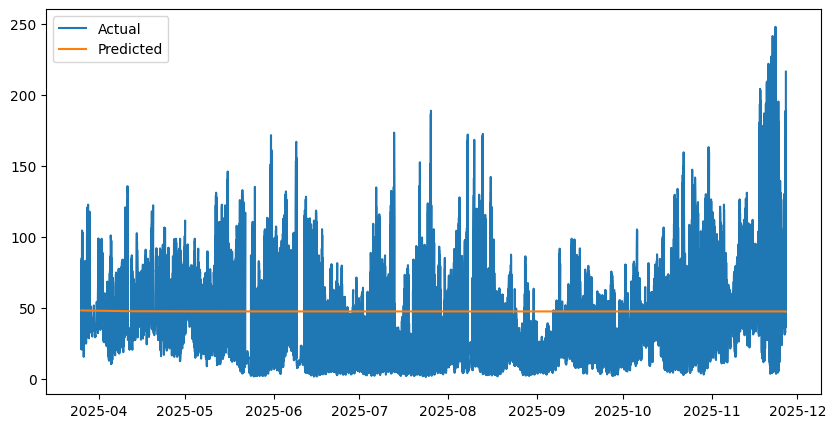

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, predictions, label="Predicted")
plt.legend()
plt.show()

## ARIMA Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 37.46846815933818


## Prophet Model

In [ ]:
prophet_data = data.reset_index()[["Datetime", "PM2_5_ugm3"]]
prophet_data.columns = ["ds", "y"]

In [ ]:
train_size = int(len(prophet_data) * 0.8)

train_prophet = prophet_data[:train_size]
test_prophet = prophet_data[train_size:]

In [ ]:
from prophet import Prophet

model = Prophet()
model.fit(train_prophet)

In [ ]:
future = model.make_future_dataframe(periods=len(test_prophet), freq='H')

/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  dates = pd.date_range(


In [ ]:
forecast = model.predict(future)

In [ ]:
forecast_test = forecast.tail(len(test_prophet))

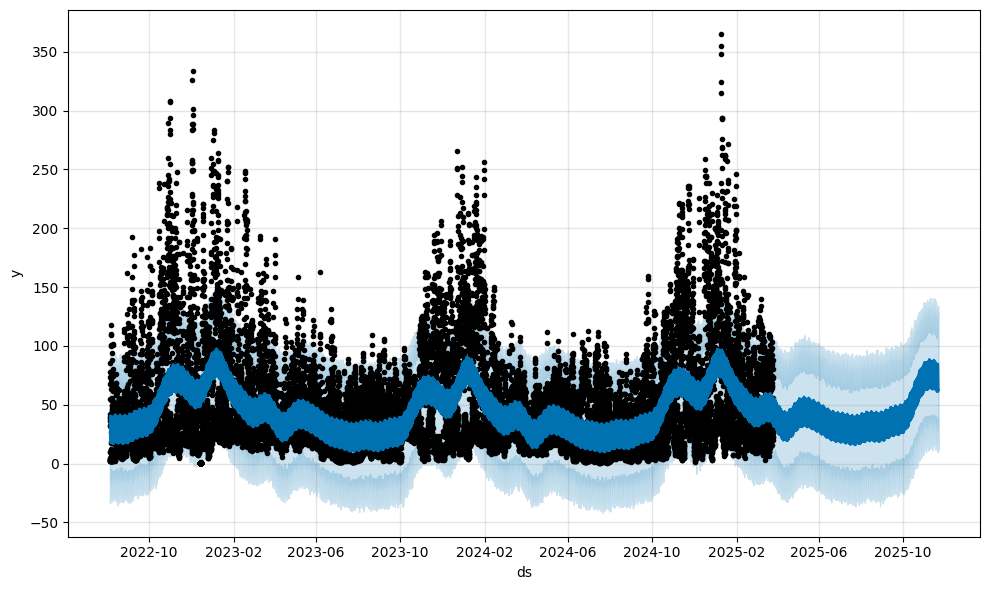

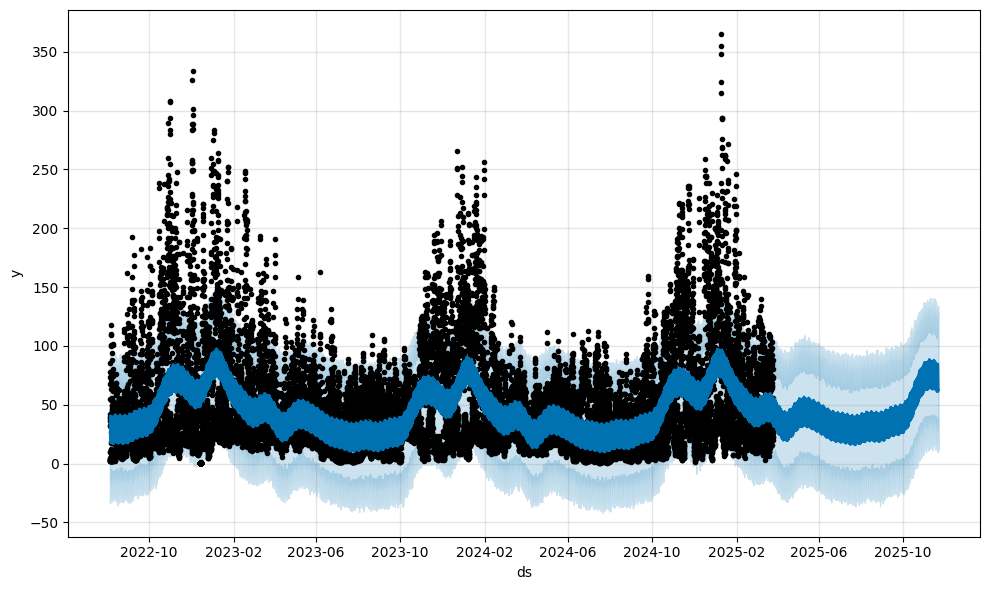

In [ ]:
model.plot(forecast)

## Prophet Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_prophet["y"], forecast_test["yhat"]))
print("Prophet RMSE:", rmse)

Prophet RMSE: 37.272645103605015


## LSTM Model

In [ ]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(ts.values.reshape(-1,1))

In [ ]:
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data)-seq_length):
        X.append(data[i:i+seq_length])
        y.append(data[i+seq_length])
    return np.array(X), np.array(y)

seq_length = 10
X, y = create_sequences(scaled_data, seq_length)

In [ ]:
train_size = int(len(X) * 0.8)

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()
model.add(LSTM(50, input_shape=(X_train.shape[1], 1)))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs=5, batch_size=32)

Epoch 1/5
722/722 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - loss: 0.0091
Epoch 2/5
722/722 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0078
Epoch 3/5
722/722 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0077
Epoch 4/5
722/722 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0076
Epoch 5/5
722/722 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.0074


In [ ]:
predictions = model.predict(X_test)

181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step


In [ ]:
predictions = scaler.inverse_transform(predictions)
y_test_actual = scaler.inverse_transform(y_test)

## LSTM Evaluation

In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test_actual, predictions))
print("LSTM RMSE:", rmse)

LSTM RMSE: 31.53600632887766


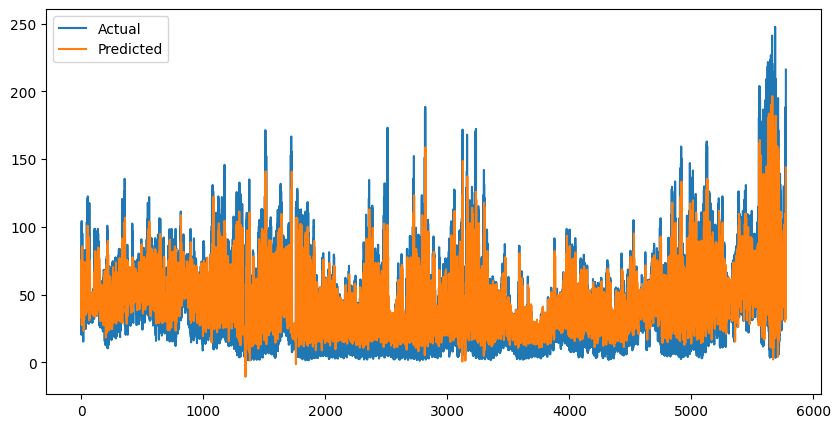

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test_actual, label="Actual")
plt.plot(predictions, label="Predicted")
plt.legend()
plt.show()

## Model Comparison

- ARIMA RMSE: 37.47  
- Prophet RMSE: 37.27  
- LSTM RMSE: 31.54  

### LSTM performed the best among all models.

## Conclusion

### In this project, ARIMA, Prophet, and LSTM models were used to forecast PM2.5 levels. Among them, LSTM achieved the lowest RMSE, indicating better performance in capturing complex patterns.